# Oil vs S&P 500 Event Analyzer
### Python Project — Full Document

**Team Members:**
- Anika Chakraborty
- Maitrayee Anand Vishnu
- Monika Khandoyan
- Nidhi Tangam Dayananda

**Data Coverage:** December 2014 – March 2026 | 2,828 Trading Days  
**Data Sources:** Bloomberg Terminal (original) / Yahoo Finance via `yfinance` (multi-stock extension)

---

## Project Overview

This project analyses the dynamic relationship between crude oil prices and equity markets across 2,828 trading days from December 2014 to March 2026. The analysis is structured in two connected parts:

**Part A — Oil vs S&P 500 (Original Analysis)**  
Using a custom Python package (`oil_spx_analyzer`), we examine how oil price movements relate to the broad S&P 500 index across eight major geopolitical and macroeconomic event windows. A simple OLS regression establishes the baseline relationship.

**Part B — Multi-Stock Multiple Regression Extension**  
We extend the analysis to 26 individual S&P 500 stocks across 6 sectors using a multiple regression model that controls for broad market returns and the VIX volatility index:

> `Stock_i(t) = α + β₁·Oil(t) + β₂·SPX(t) + β₃·VIX(t) + ε`

The controlled coefficient **β₁** — the *pure* oil sensitivity — is the central measure of Part B.

---

## Table of Contents
| Section | Description |
|---|---|
| **Setup** | Libraries, package imports, data loading |
| **Part A — §1** | Log returns, volatility, oil shock detection |
| **Part A — §2** | Event impact analysis across 8 geopolitical events |
| **Part A — §3** | Price, return & rolling correlation charts |
| **Part A — §4** | Shock scatter, Iran War deep-dive, event comparison |
| **Part A — §5** | Full console report |
| **Part A — §6** | Simple OLS regression (baseline) |
| **Part B — §1** | Multi-stock data loading (Yahoo Finance) |
| **Part B — §2** | Multiple regression — all 26 stocks |
| **Part B — §3** | Oil beta ranking & sector heatmap |
| **Part B — §4** | Rolling pure-oil beta over time |
| **Part B — §5** | Event window analysis — all stocks |
| **Part B — §6** | Beta vs actual return — model validation |
| **Part B — §7** | Individual stock deep-dive |
| **Conclusions** | Unified findings across both parts |

---
## Setup — Libraries & Package Imports

Installing `yfinance` (needed for Part B), importing standard scientific Python libraries,
and loading all modules from the `oil_spx_analyzer` package.

In [1]:
import subprocess, sys, warnings, os
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

# Install yfinance for Part B data loading (safe to run if already installed)
subprocess.run([sys.executable, "-m", "pip", "install", "yfinance", "-q"], check=True)

sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

# ── Original package modules ────────────────────────────────────────────────
from oil_spx_analyzer.data_loader import load_data
from oil_spx_analyzer.analyzer   import (compute_returns, rolling_correlation,
                                          volatility, simple_regression,
                                          shock_detector)
from oil_spx_analyzer.events     import get_events, event_analysis
from oil_spx_analyzer.report     import (generate_report, plot_prices,
                                          plot_returns, plot_rolling_correlation,
                                          plot_event_windows, plot_shocks,
                                          plot_iran_war, plot_event_comparison,
                                          plot_regression)

# ── Multi-stock extension module ─────────────────────────────────────────────
from oil_spx_analyzer.multi_stock import (
    SECTORS, SECTOR_COLOURS,
    load_multi_stock_data, compute_multi_returns,
    multi_regression, compute_all_betas,
    rolling_oil_beta, event_multi_analysis,
    plot_beta_ranking, plot_sector_heatmap, plot_rolling_betas,
    plot_event_beta_scatter, plot_event_heatmap,
    print_multi_regression_report,
)

print("All libraries imported ✓")
print(f"Part B coverage: {len(SECTORS)} stocks across {len(set(SECTORS.values()))} sectors")
for sector in sorted(set(SECTORS.values())):
    tickers_in = [t for t, s in SECTORS.items() if s == sector]
    print(f"  {sector:<14}: {', '.join(tickers_in)}")

All libraries imported ✓
Part B coverage: 26 stocks across 7 sectors
  Airlines      : DAL, LUV, AAL, UAL
  Consumer      : AMZN, WMT, MCD
  Energy        : XOM, CVX, COP, SLB, EOG
  Financials    : JPM, GS, BAC, WFC
  Healthcare    : JNJ, UNH
  Industrials   : BA, CAT, GE
  Technology    : AAPL, MSFT, NVDA, GOOGL, META


---
## Part A — §1 · Load Price Data

Loading the daily S&P 500 (SPX) and crude oil (CL1) closing prices.

**Data source priority:**
1. Bloomberg Terminal Excel export (`Bloomberg data.xlsx`) — used in the original analysis
2. Yahoo Finance via `yfinance` — automatic fallback if the Excel file is not found

Both paths produce a DataFrame with identical structure: a `DatetimeIndex` and two columns
`['SPX', 'Oil']`, so all downstream code runs unchanged regardless of source.

In [2]:
import os

BLOOMBERG_FILE = "Bloomberg data.xlsx"   # ← change filename here if needed

if os.path.exists(BLOOMBERG_FILE):
    # ── Path 1: original Bloomberg data ────────────────────────────────────
    prices_ab = load_data(BLOOMBERG_FILE)
    print(f"Loaded from Bloomberg Excel: {prices_ab.shape[0]:,} trading days")

else:
    # ── Path 2: Yahoo Finance fallback ──────────────────────────────────────
    print("Bloomberg file not found — downloading Oil + SPX from Yahoo Finance …")
    import yfinance as yf
    raw = yf.download(["CL=F", "^GSPC"], start="2014-12-01", end="2026-03-31",
                      auto_adjust=True, progress=True)["Close"]
    raw = raw.rename(columns={"CL=F": "Oil", "^GSPC": "SPX"})
    raw = raw.dropna()
    prices_ab = raw
    print(f"Downloaded from Yahoo Finance: {prices_ab.shape[0]:,} trading days")

print(f"Date range  : {prices_ab.index[0].date()} → {prices_ab.index[-1].date()}")
print(f"Columns     : {list(prices_ab.columns)}")
prices_ab.tail(3)

Data loaded: 2828 trading days (2014-12-31 to 2026-03-31)
Loaded from Bloomberg Excel: 2,828 trading days
Date range  : 2014-12-31 → 2026-03-31
Columns     : ['SPX', 'Oil']


,SPX,Oil
Date,,
2026-03-27,6368.85,99.64
2026-03-30,6343.72,102.88
2026-03-31,6528.52,101.38


---
## Part A — §2 · Log Returns, Volatility & Oil Price Shocks

- **Log returns:** `r(t) = ln(P(t) / P(t−1))` — time-additive and approximately normally distributed
- **Volatility:** annualised standard deviation of daily log returns (`σ × √252`)
- **Oil shock days:** any day where |oil log return| > 3% — captures extreme energy market moves

In [15]:
returns_ab = compute_returns(prices_ab)
vols       = volatility(returns_ab)
corr       = rolling_correlation(returns_ab, window=30)
shocks     = shock_detector(returns_ab, threshold=0.03)

# Detect the oil-return column name robustly
oil_col = next(
    (c for c in shocks.columns if "oil" in c.lower() or "return" in c.lower()),
    shocks.columns[0]
)

print("=" * 48)
print("  VOLATILITY SUMMARY")
print("=" * 48)
print(f"  S&P 500 annualised volatility : {vols['SPX']:.2%}")
print(f"  Oil annualised volatility     : {vols['Oil']:.2%}")
print(f"  Oil is {vols['Oil'] / vols['SPX']:.1f}x more volatile than the S&P 500")
print("=" * 48)
print()
print(f"  Oil shock days (|return| > 3%) : {len(shocks):,}")
print(f"  As % of all trading days       : {len(shocks) / len(returns_ab):.1%}")
print(f"  Positive shocks (price spike)  : {(shocks[oil_col] > 0).sum():,}")
print(f"  Negative shocks (price crash)  : {(shocks[oil_col] < 0).sum():,}")

  VOLATILITY SUMMARY
  S&P 500 annualised volatility : 17.86%
  Oil annualised volatility     : 45.70%
  Oil is 2.6x more volatile than the S&P 500

  Oil shock days (|return| > 3%) : 491
  As % of all trading days       : 17.4%
  Positive shocks (price spike)  : 229
  Negative shocks (price crash)  : 262


---
## Part A — §3 · Event Impact Analysis

Measuring cumulative returns and within-event oil–SPX correlation across 8 key geopolitical
and macroeconomic events. This table is the core output of the original analysis —
it establishes that the oil–equity relationship is not static.

In [16]:
events        = get_events()
event_results = event_analysis(returns_ab, events)

event_results[[
    "Trading Days",
    "Oil Cumulative Return",
    "SPX Cumulative Return",
    "Oil-SPX Correlation"
]].astype(float).round(4)

,Trading Days,Oil Cumulative Return,SPX Cumulative Return,Oil-SPX Correlation
Iran: Soleimani Killing (Jan 2020),21.0,-0.1691,-0.0016,0.1134
COVID-19 Crash,50.0,-0.4145,-0.0997,0.2701
Oil Price War (Mar 2020),23.0,-0.7902,-0.1788,0.4269
Post-COVID Recovery,170.0,0.9460,0.2544,0.3798
Russia-Ukraine War,62.0,0.1720,-0.0888,-0.1763
Iran: Israel First Strikes (Jun 2025),8.0,-0.0469,0.0077,-0.9180
Iran: Full US-Israel War (Feb 2026),22.0,0.4139,-0.0523,-0.5022
Iran: Hormuz Closure & Ceasefire Talks,22.0,0.4139,-0.0523,-0.5022


---
## Part A — §4 · Price Series & Daily Log Returns

**Figure 1:** Normalised price series (base = 100 at December 2014) — shows oil's substantially
greater volatility over the full period, with multiple severe drawdown episodes.

**Figure 2:** Daily log returns for both assets — both exhibit clear volatility clustering,
with the largest spikes coinciding with the event windows.

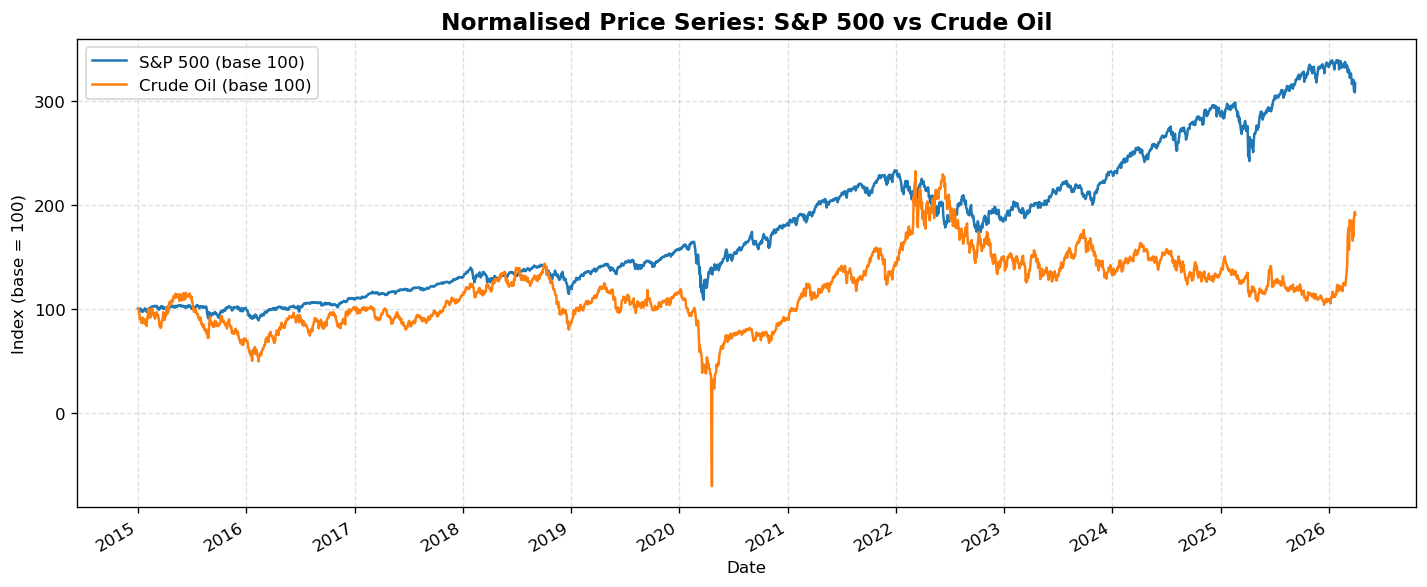

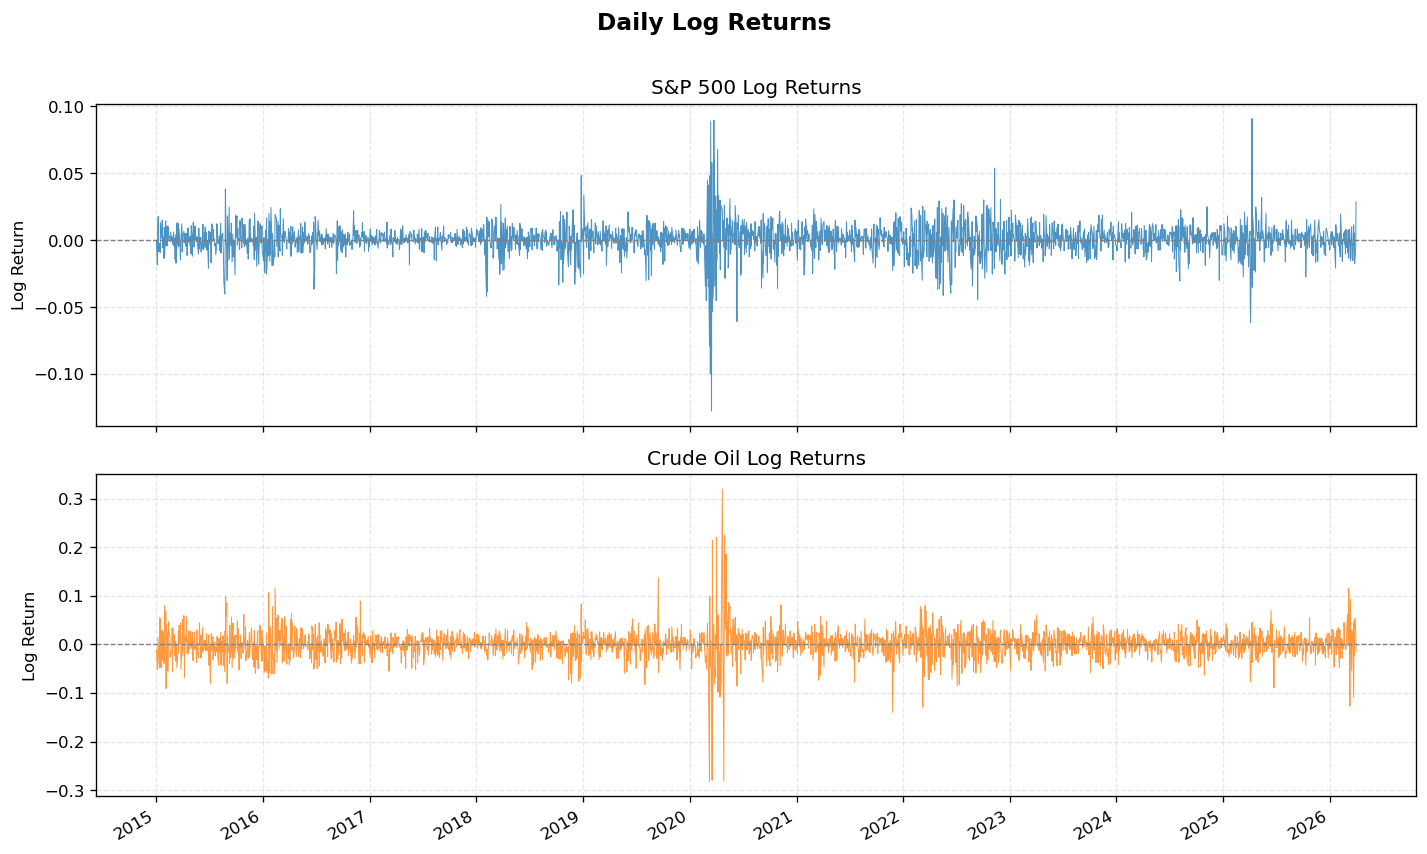

In [17]:
plot_prices(prices_ab)
plot_returns(returns_ab)

---
## Part A — §5 · Rolling Correlation & Event Window Charts

**Figure 3:** 30-day rolling Pearson correlation between oil and S&P 500 returns.
The correlation fluctuates from strongly positive (+0.8) to strongly negative (−0.9),
confirming that a single static figure cannot characterise this relationship.

**Figure 4:** Normalised price behaviour during each individual event window
(base = 100 at start of each event).

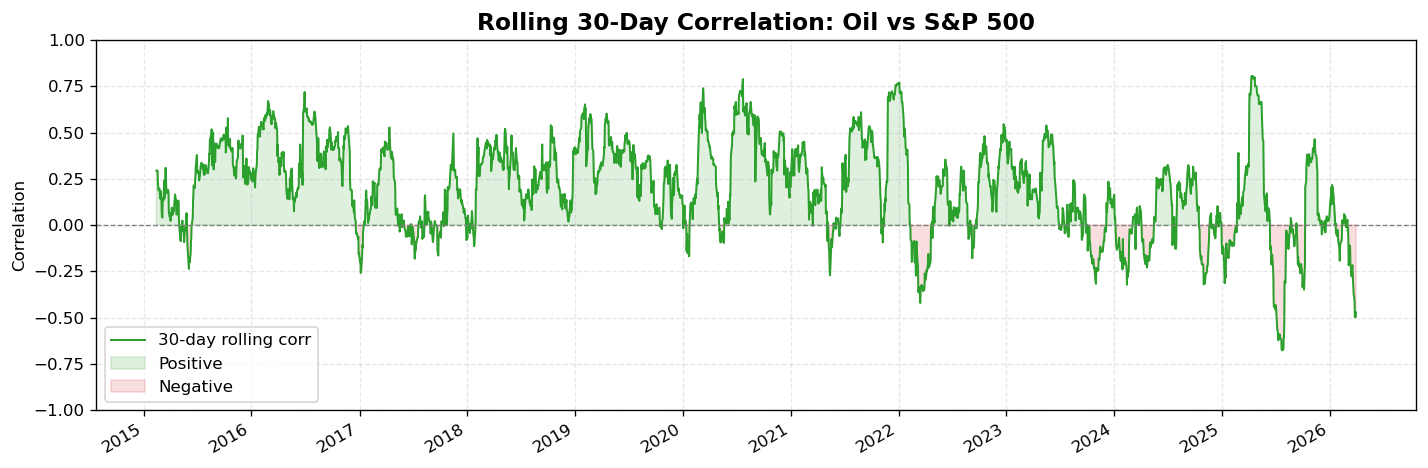

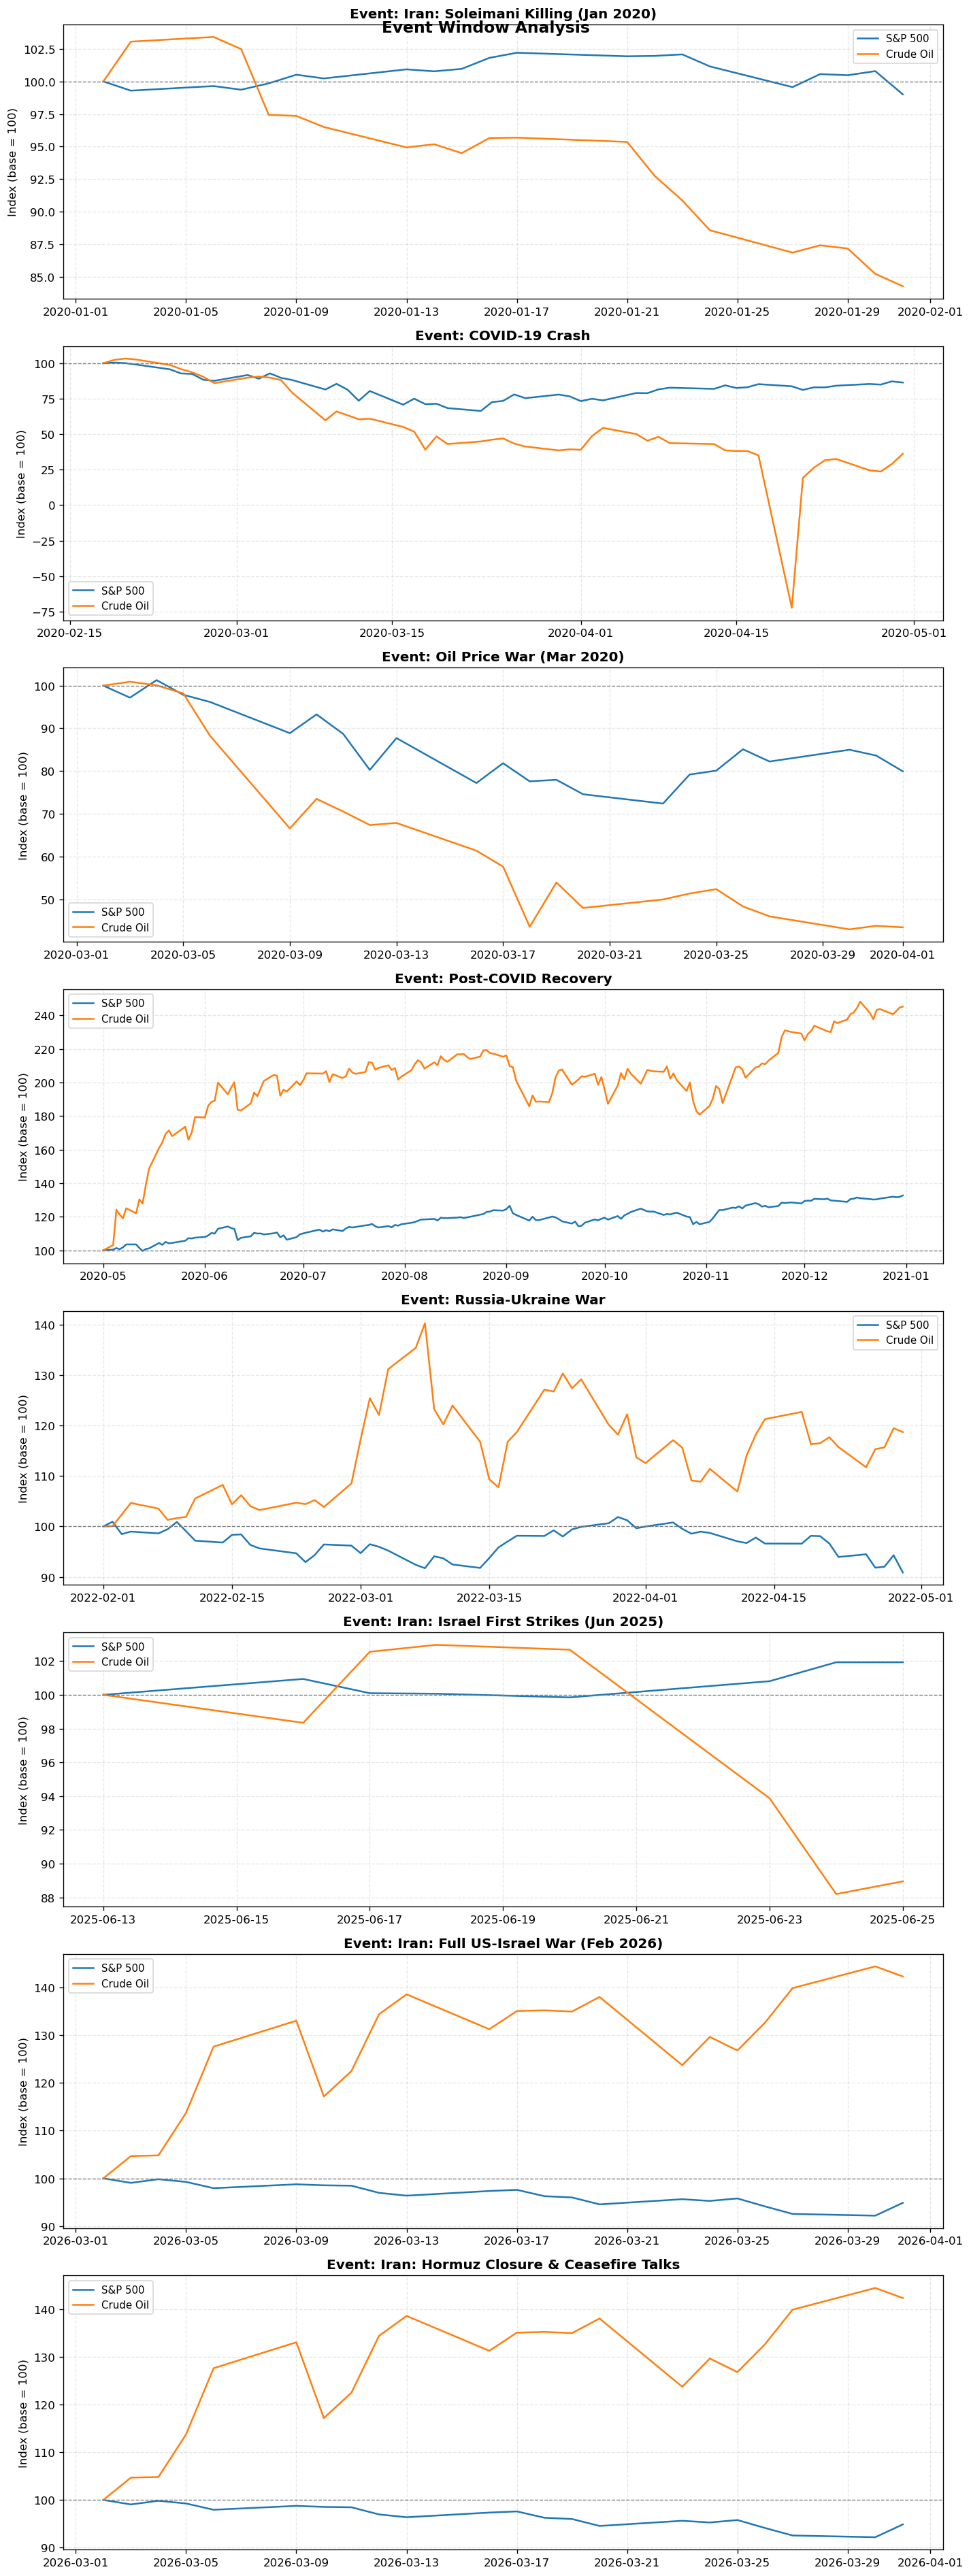

In [18]:
plot_rolling_correlation(corr, window=30)
plot_event_windows(prices_ab, events)

---
## Part A — §6 · Oil Shock Analysis & Iran War Deep-Dive

**Figure 5:** Oil shock days — oil log return (x-axis) vs same-day S&P 500 return (y-axis).
Reveals the asymmetry between supply-driven and demand-driven shocks.

**Figure 6:** Iran War 2025–2026 deep-dive — normalised prices with event markers (top panel)
and 10-day rolling correlation (bottom panel).

**Figure 7:** Cumulative return comparison across all 8 events — oil (orange) vs S&P 500 (blue).

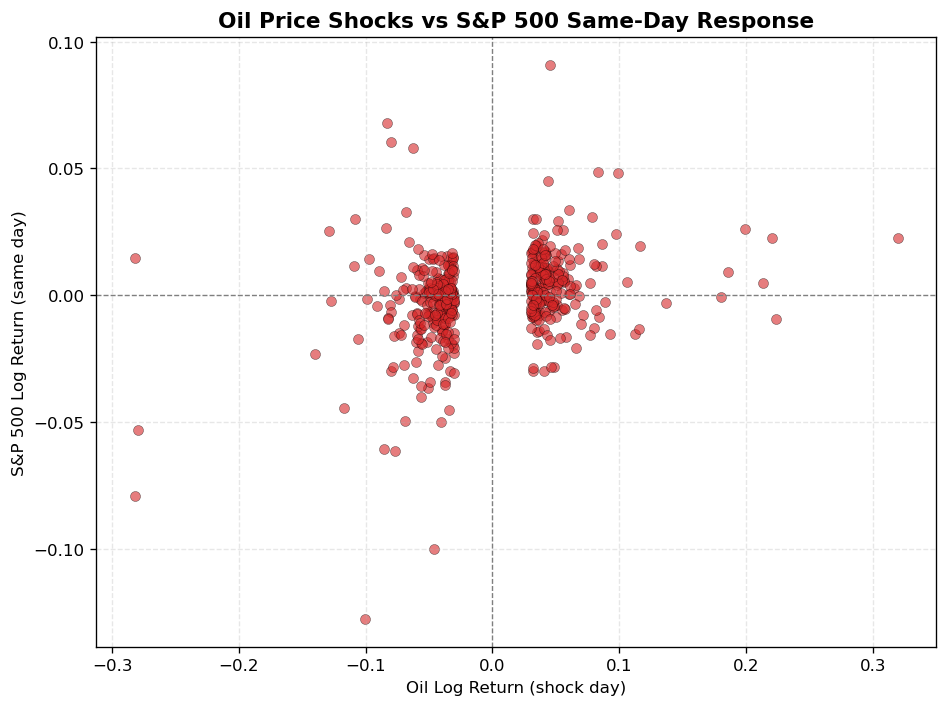

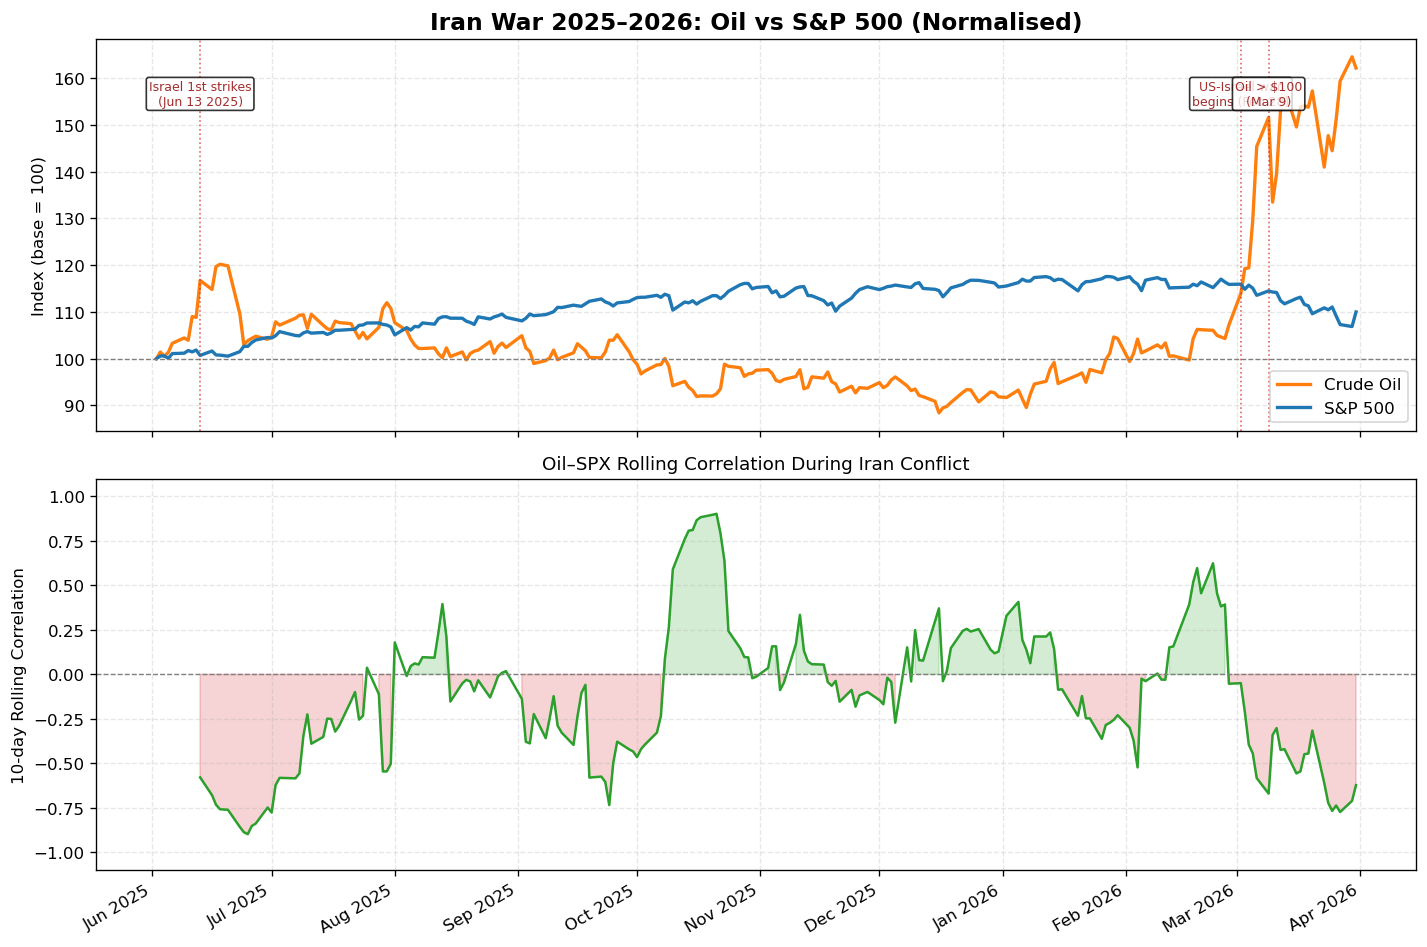

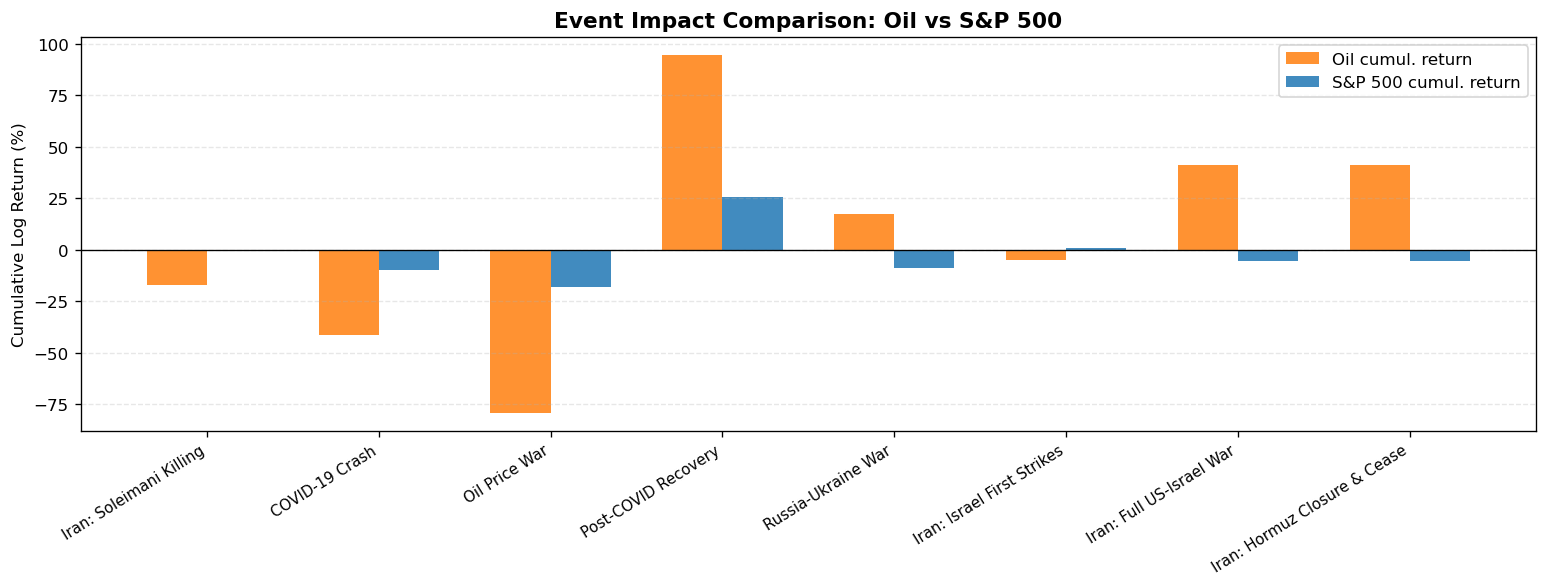

In [19]:
plot_shocks(shocks, returns_ab)
plot_iran_war(prices_ab, returns_ab)
plot_event_comparison(event_results)

---
## Part A — §7 · Full Event Impact Report

Complete formatted summary — volatility, total shock days, and detailed statistics
for every event window: trading days, average daily return, cumulative return,
and within-event oil–SPX correlation.

In [20]:
generate_report(event_results, vols, shocks)


  OIL vs S&P 500 EVENT IMPACT REPORT

── ASSET VOLATILITY (annualised) ──
  SPX  : 17.86%
  Oil  : 45.70%

── OIL PRICE SHOCKS DETECTED (|return| > 3%) ──
  Total shock days: 491
  Positive oil shocks (price spike): 229
  Negative oil shocks (price crash): 262

── EVENT ANALYSIS ──

  Iran: Soleimani Killing (Jan 2020)
    Period         : 2020-01-01 → 2020-02-01
    Trading Days   : 21
    Oil Avg Return : -0.8053%
    Oil Cum Return : -16.9111%
    SPX Avg Return : -0.0078%
    SPX Cum Return : -0.1629%
    Correlation    : 0.1134

  COVID-19 Crash
    Period         : 2020-02-15 → 2020-04-30
    Trading Days   : 50
    Oil Avg Return : -0.8291%
    Oil Cum Return : -41.4547%
    SPX Avg Return : -0.1995%
    SPX Cum Return : -9.9737%
    Correlation    : 0.2701

  Oil Price War (Mar 2020)
    Period         : 2020-03-01 → 2020-04-01
    Trading Days   : 23
    Oil Avg Return : -3.4357%
    Oil Cum Return : -79.0202%
    SPX Avg Return : -0.7775%
    SPX Cum Return : -17.8814%
    C

---
## Part A — §8 · Simple OLS Regression (Baseline)

Full-sample simple regression: `SPX(t) = α + β·Oil(t) + ε`

This is the **baseline model**. The low R² (≈5.4%) despite a highly significant β
motivates the multi-regressor extension in Part B — oil alone is a poor predictor of
individual equity returns, but the relationship differs dramatically by sector.

  SIMPLE OLS REGRESSION  —  SPX ~ Oil
  α (intercept)  : 0.000386
  β (slope)      : 0.091019
  R-squared      : 0.0542
  t-statistic    : 12.7252
  p-value        : 4.2835e-37
  Observations   : 2,825

Interpretation:
  A 1% move in oil → 9.1019% move in S&P 500
  Oil explains 5.42% of daily S&P 500 variation

Limitation of this model:
  β mixes the direct oil effect with any market-wide move that
  happened to coincide with oil on the same day. Part B removes
  this contamination by controlling for SPX and VIX.


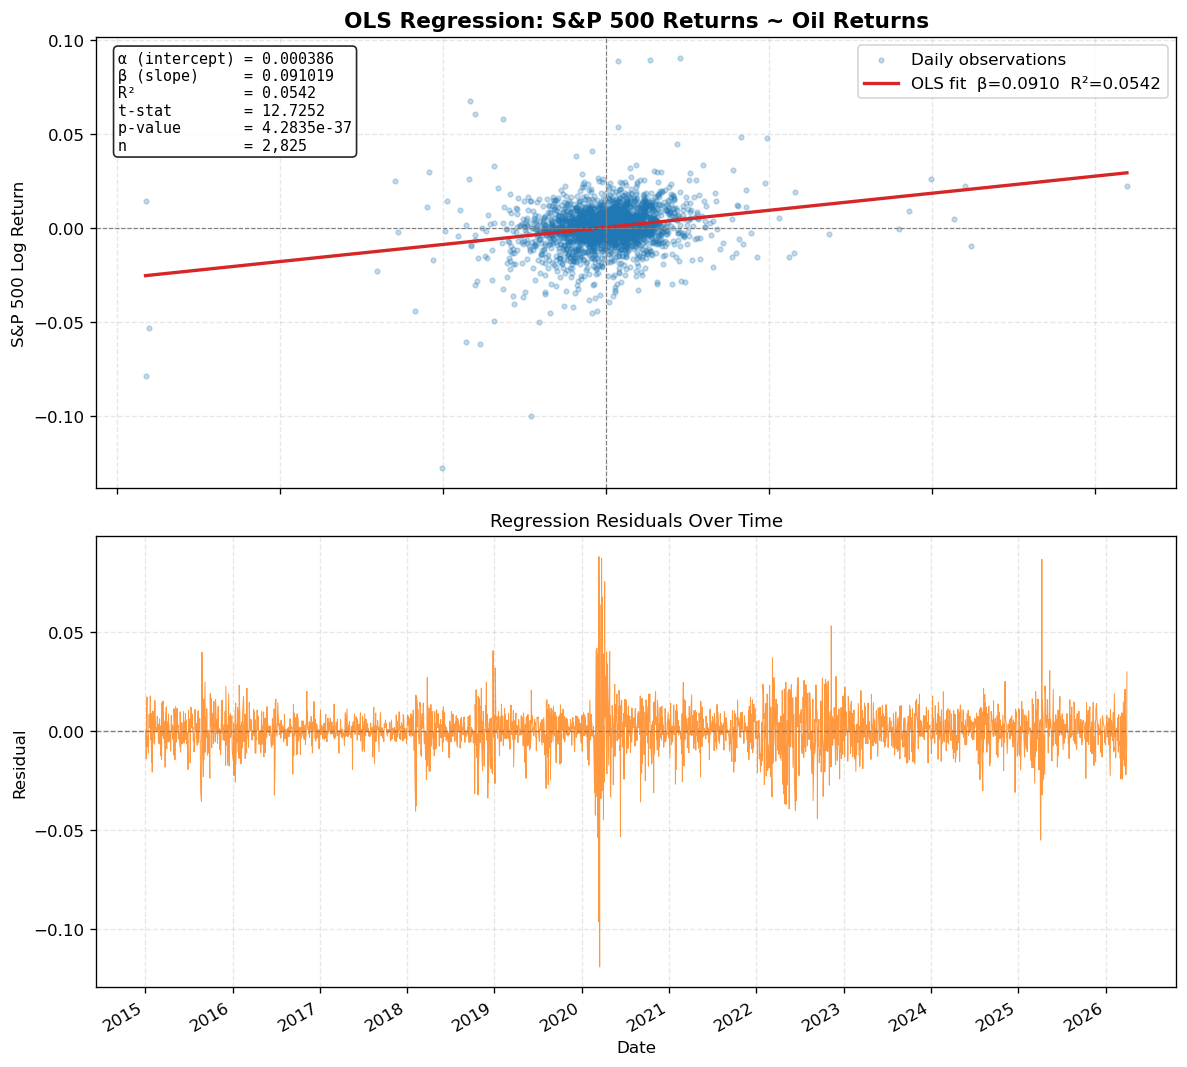

In [21]:
reg = simple_regression(returns_ab)

print("=" * 48)
print("  SIMPLE OLS REGRESSION  —  SPX ~ Oil")
print("=" * 48)
print(f"  α (intercept)  : {reg['alpha']:.6f}")
print(f"  β (slope)      : {reg['beta']:.6f}")
print(f"  R-squared      : {reg['r_squared']:.4f}")
print(f"  t-statistic    : {reg['t_stat']:.4f}")
print(f"  p-value        : {reg['p_value']:.4e}")
print(f"  Observations   : {reg['n']:,}")
print("=" * 48)
print()
print("Interpretation:")
print(f"  A 1% move in oil → {reg['beta']*100:.4f}% move in S&P 500")
print(f"  Oil explains {reg['r_squared']*100:.2f}% of daily S&P 500 variation")
print()
print("Limitation of this model:")
print("  β mixes the direct oil effect with any market-wide move that")
print("  happened to coincide with oil on the same day. Part B removes")
print("  this contamination by controlling for SPX and VIX.")

plot_regression(returns_ab, reg)

---

## From Part A → Part B

The simple regression in §8 established that oil and the S&P 500 are weakly correlated
on average (R² = 0.054) but that this relationship collapses or reverses during geopolitical
shocks. Two limitations remain:

**Limitation 1 — The index masks sector heterogeneity.**  
The S&P 500 averages across energy producers (who benefit from high oil prices),
airlines (who are harmed), and technology firms (largely unaffected). A single beta
hides opposite-sign effects within the index.

**Limitation 2 — β is contaminated by market-wide comovement.**  
If oil and equities both fall on the same day because of a recession scare, the
simple regression attributes that co-movement to oil even though the real driver is
the macro environment.

**Part B solves both problems:**
- Running separate regressions for 26 individual S&P 500 stocks
- Adding SPX and VIX as control regressors so that β₁ (oil sensitivity) is isolated
  from broad market direction and volatility regime effects

> `Stock_i(t) = α + β₁·Oil(t) + β₂·SPX(t) + β₃·VIX(t) + ε`

---
## Part B — §1 · Multi-Stock Price Data (Yahoo Finance)

Downloads 26 major S&P 500 stocks + Oil + SPX + VIX via `yfinance`.
Results are cached to `multi_stock_data.csv` — the first run takes ~30 seconds;
subsequent runs load from disk instantly.

In [22]:
prices_mb = load_multi_stock_data(
    start="2014-12-01",
    end="2026-03-31",
    cache_path="multi_stock_data.csv"
)

print(f"Shape       : {prices_mb.shape[0]:,} trading days × {prices_mb.shape[1]} assets")
print(f"Date range  : {prices_mb.index[0].date()} → {prices_mb.index[-1].date()}")

missing = prices_mb.isnull().sum()
missing = missing[missing > 0]
print(f"Missing values: {'None — all columns complete ✓' if missing.empty else ''}")
if not missing.empty:
    print(missing.to_string())

prices_mb[["Oil", "SPX", "VIX", "XOM", "DAL", "AAPL", "JPM"]].tail(3)

Loading cached data from multi_stock_data.csv
Shape       : 2,846 trading days × 29 assets
Date range  : 2014-12-01 → 2026-03-30
Missing values: None — all columns complete ✓


,Oil,SPX,VIX,XOM,DAL,AAPL,JPM
Date,,,,,,,
2026-03-26,94.480003,6477.160156,27.440001,164.314713,66.683090,252.657227,290.174957
2026-03-27,99.639999,6368.850098,31.049999,169.837234,64.658463,248.570984,281.399872
2026-03-30,102.879997,6343.720215,30.610001,170.313995,63.022797,246.402985,282.325134


---
## Part B — §2 · Log Returns — All Assets

Daily log returns computed uniformly for all 29 columns.
`Oil`, `SPX`, and `VIX` will serve as regressors; all stock columns are dependent variables.

In [23]:
returns_mb = compute_multi_returns(prices_mb)

print(f"Returns shape : {returns_mb.shape[0]:,} obs × {returns_mb.shape[1]} assets\n")
ann_vol = returns_mb.std() * np.sqrt(252) * 100

print(f"{'Ticker':<7} {'Sector':<14} {'Ann. Vol':>9}")
print("-" * 33)
highlight = ["Oil","SPX","VIX","XOM","CVX","DAL","AAL","AAPL","NVDA","JPM","BA","JNJ"]
for t in highlight:
    if t in ann_vol:
        sec = SECTORS.get(t, "Benchmark")
        print(f"{t:<7} {sec:<14} {ann_vol[t]:>8.2f}%")

Returns shape : 2,843 obs × 29 assets

Ticker  Sector          Ann. Vol
---------------------------------
Oil     Benchmark         45.69%
SPX     Benchmark         17.83%
VIX     Benchmark        128.47%
XOM     Energy            27.41%
CVX     Energy            29.21%
DAL     Airlines          40.98%
AAL     Airlines          50.47%
AAPL    Technology        28.69%
NVDA    Technology        47.73%
JPM     Financials        27.02%
BA      Industrials       39.77%
JNJ     Healthcare        18.20%


---
## Part B — §3 · Multiple Regression — All 26 Stocks

Running `Stock_i = α + β₁·Oil + β₂·SPX + β₃·VIX + ε` for every stock using NumPy
normal equations. The key output is **β₁ (Beta_Oil)** — the pure oil sensitivity
after controlling for the broad market and volatility regime.

In [24]:
betas_df = compute_all_betas(returns_mb)

# Display formatted results table
display_cols = ["Sector", "Beta_Oil", "Beta_SPX", "Beta_VIX", "Adj_R2", "T_Oil", "P_Oil"]
styled = betas_df[display_cols].sort_values(["Sector", "Beta_Oil"]).copy()
styled.columns = ["Sector", "β_Oil (pure)", "β_SPX", "β_VIX", "Adj R²", "t(oil)", "p(oil)"]
styled.round(4)

,Sector,β_Oil (pure),β_SPX,β_VIX,Adj R²,t(oil),p(oil)
Ticker,,,,,,,
AAL,Airlines,-0.0958,1.4072,-0.0113,0.2548,-5.2110,0.0000
LUV,Airlines,-0.0648,1.0308,-0.0139,0.2740,-4.8991,0.0000
UAL,Airlines,-0.0517,1.4269,-0.0156,0.2794,-2.8792,0.0081
DAL,Airlines,-0.0481,1.2802,-0.0119,0.3299,-3.3980,0.0014
WMT,Consumer,-0.0302,0.5529,0.0046,0.1816,-3.6683,0.0005
AMZN,Consumer,-0.0281,1.1049,-0.0156,0.4094,-2.6487,0.0162
MCD,Consumer,-0.0072,0.7194,0.0147,0.3204,-1.0298,0.6149
XOM,Energy,0.2423,0.7050,0.0063,0.4357,27.8757,0.0000
CVX,Energy,0.2438,0.9299,0.0225,0.4810,27.4399,0.0000


---
## Part B — §4 · Multi-Regression Console Report

Full formatted summary table grouped by sector, with significance stars (***/**/*),
and identification of the most and least oil-sensitive stocks in the universe.

In [25]:
print_multi_regression_report(betas_df)

  MULTI-REGRESSION RESULTS  —  Stock = α + β1·Oil + β2·SPX + β3·VIX + ε
  Ticker  Sector           β_Oil    β_SPX    β_VIX   Adj R²   t(oil)   Sig
----------------------------------------------------------------------------------
  ── Airlines ──
  AAL     Airlines       -0.0958   1.4072  -0.0113   0.2548    -5.21   ***
  LUV     Airlines       -0.0648   1.0308  -0.0139   0.2740    -4.90   ***
  UAL     Airlines       -0.0517   1.4269  -0.0156   0.2794    -2.88    **
  DAL     Airlines       -0.0481   1.2802  -0.0119   0.3299    -3.40    **

  ── Consumer ──
  WMT     Consumer       -0.0302   0.5529   0.0046   0.1816    -3.67   ***
  AMZN    Consumer       -0.0281   1.1049  -0.0156   0.4094    -2.65     *
  MCD     Consumer       -0.0072   0.7194   0.0147   0.3204    -1.03      

  ── Energy ──
  XOM     Energy          0.2423   0.7050   0.0063   0.4357    27.88   ***
  CVX     Energy          0.2438   0.9299   0.0225   0.4810    27.44   ***
  SLB     Energy          0.3404   0.9607   

---
## Part B — §5 · Oil Beta Ranking Chart

All 26 stocks ranked from most negatively oil-sensitive (left, Airlines) to most positively
(right, Energy). Colour-coded by sector. Asterisks mark statistically significant β₁ (p < 0.05).

**Expected pattern:** Airlines < Consumer ≈ Technology < Financials < Industrials < Energy

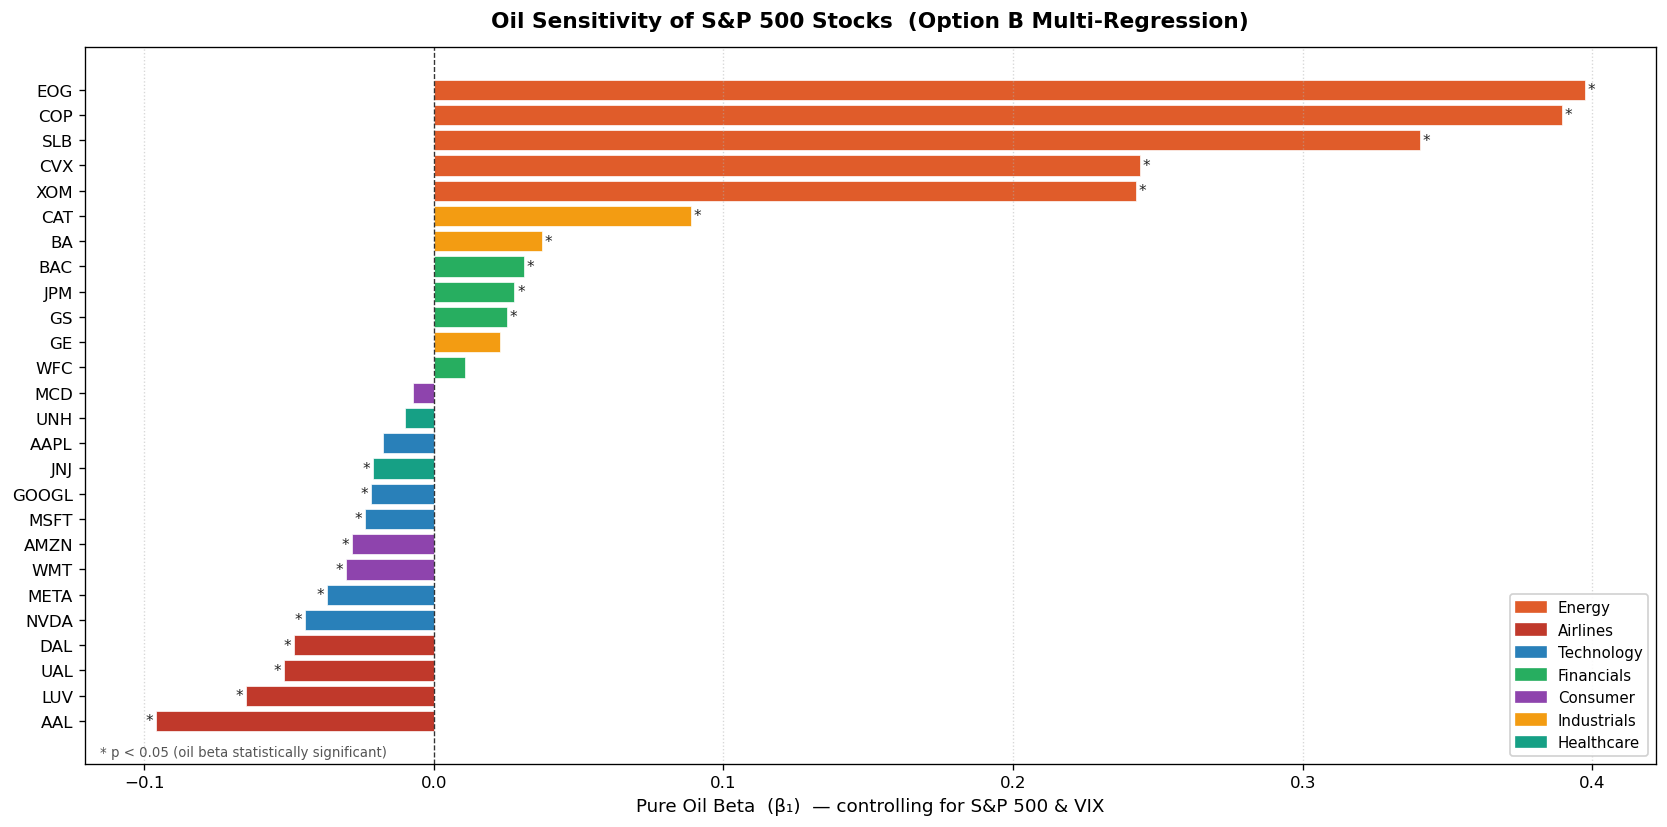

In [26]:
plot_beta_ranking(betas_df)

---
## Part B — §6 · Sector Heatmap — β_Oil & Adjusted R²

**Left panel:** Pure oil beta across all stocks — red = negative sensitivity, green = positive.  
**Right panel:** Adjusted R² — how well Oil + SPX + VIX jointly explain each stock's daily returns.

White vertical lines divide sectors. Stocks within each sector are sorted by oil beta.

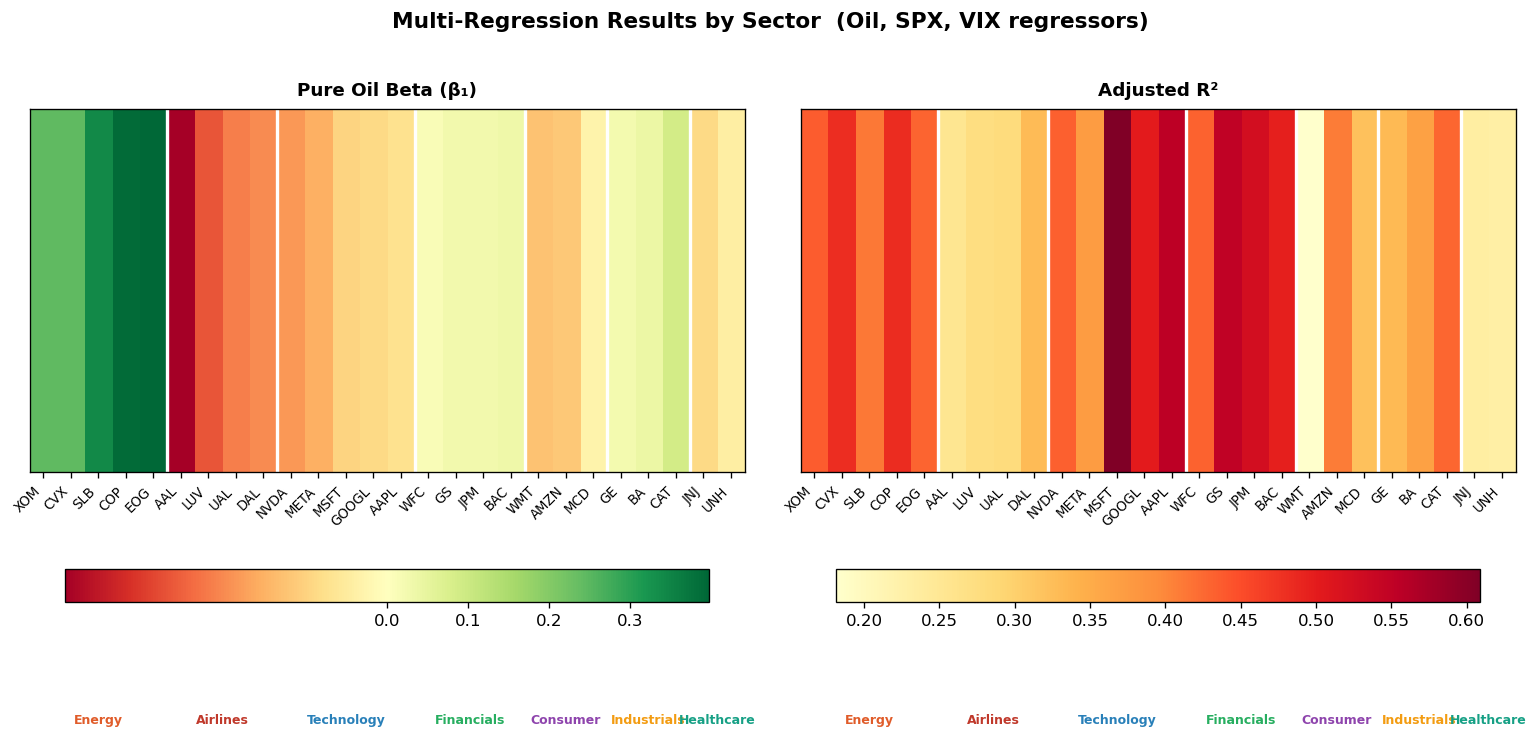

In [9]:
plot_sector_heatmap(betas_df)

---
## Part B — §7 · Rolling 60-Day Pure Oil Beta

How does each stock's oil sensitivity evolve over time?

A 60-day rolling multiple regression is computed for four representative stocks:
- **XOM** (Energy) — strongly positive; expected to spike during Iran war
- **DAL** (Airlines) — negative; worsens when oil supply is threatened
- **AAPL** (Technology) — near-zero; relatively insulated from oil dynamics
- **JPM** (Financials) — mild positive; driven by macro growth channel

Coloured bands mark the 5 major geopolitical event periods.

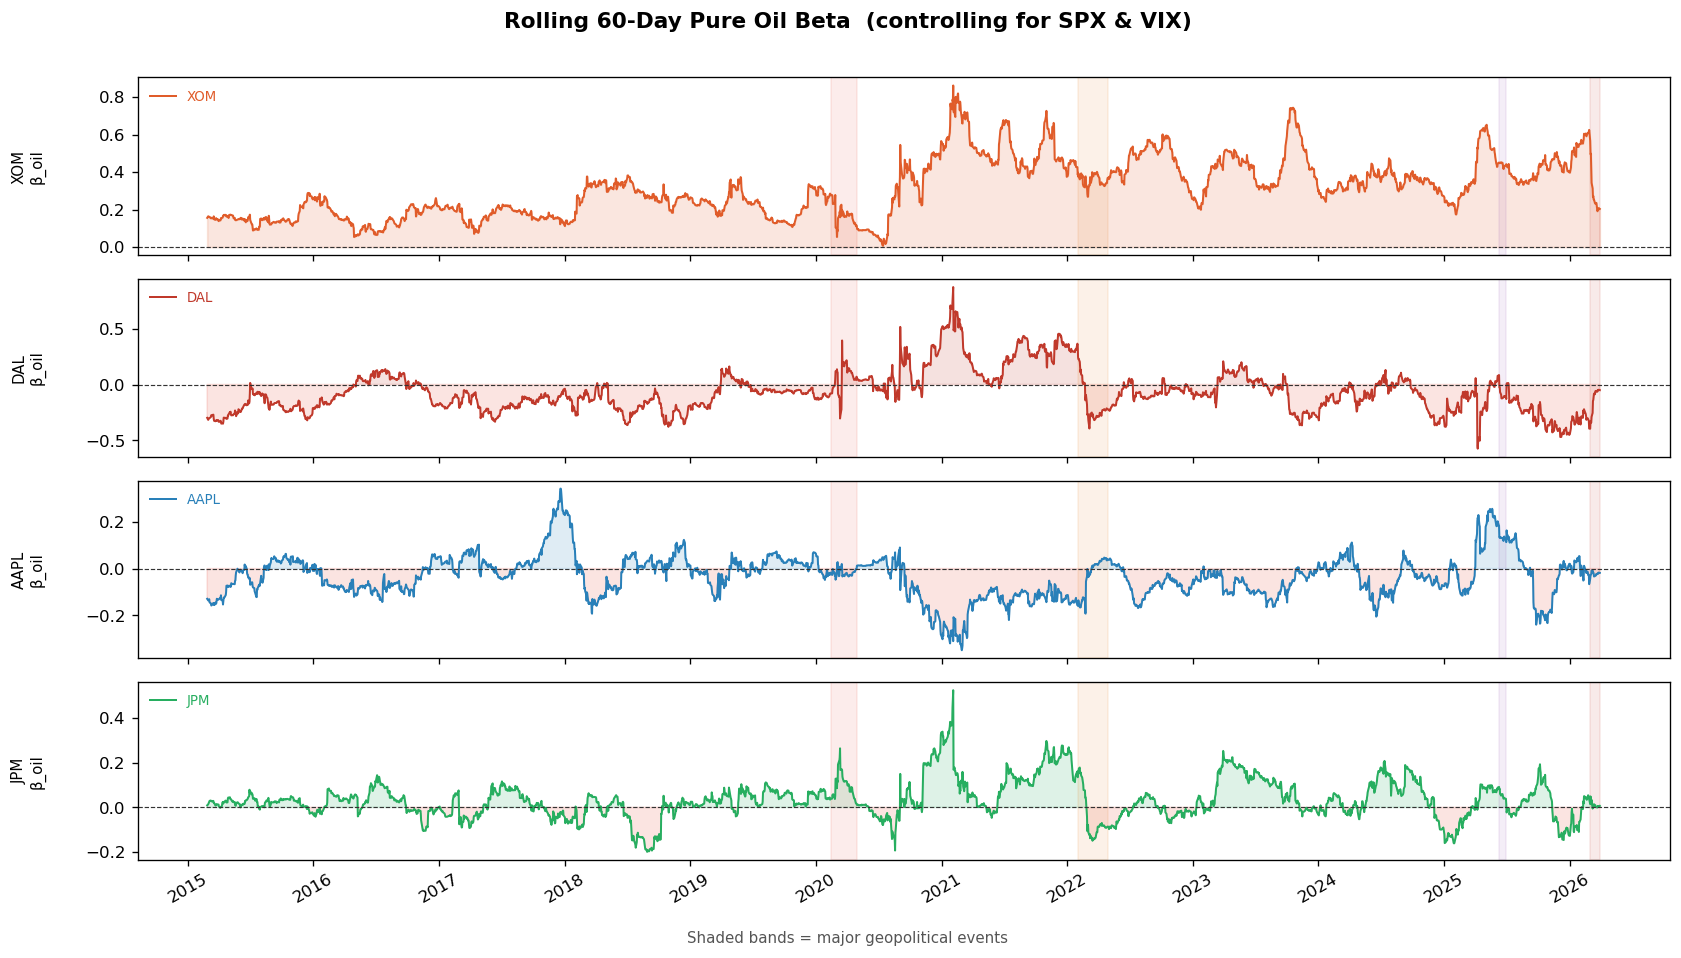

In [10]:
plot_rolling_betas(
    returns_mb,
    tickers=("XOM", "DAL", "AAPL", "JPM"),
    window=60
)

---
## Part B — §8 · Event Window Analysis — All 26 Stocks

Cumulative log returns for every stock during each of the 8 event windows.
Uses the same event definitions from Part A, now applied to 26 individual stocks.

In [11]:
# Re-use the same event list from Part A (same windows, same dates)
events_list = [
    {"name": "Iran: Soleimani Killing",  "start": "2020-01-01", "end": "2020-02-01"},
    {"name": "COVID-19 Crash",            "start": "2020-02-15", "end": "2020-04-30"},
    {"name": "Oil Price War",             "start": "2020-03-01", "end": "2020-04-01"},
    {"name": "Post-COVID Recovery",       "start": "2020-05-01", "end": "2021-01-01"},
    {"name": "Russia-Ukraine War",        "start": "2022-02-01", "end": "2022-05-01"},
    {"name": "Iran: Israel Strikes",      "start": "2025-06-13", "end": "2025-06-25"},
    {"name": "Iran: Full US-Israel War",  "start": "2026-02-28", "end": "2026-03-31"},
    {"name": "Iran: Hormuz Closure",      "start": "2026-03-01", "end": "2026-04-07"},
]

event_returns_mb = event_multi_analysis(returns_mb, events_list)

# Preview: Iran Full War — which sectors won and lost?
key = "Iran: Full US-Israel War"
if key in event_returns_mb:
    ev = (event_returns_mb[key] * 100).sort_values()
    print(f"Cumulative returns during '{key}':")
    print(f"{'Ticker':<7} {'Sector':<14} {'Return':>8}")
    print("-" * 32)
    for ticker, ret in ev.items():
        sec = SECTORS.get(ticker, "Benchmark")
        sign = "+" if ret >= 0 else ""
        print(f"{ticker:<7} {sec:<14} {sign}{ret:>7.2f}%")

Cumulative returns during 'Iran: Full US-Israel War':
Ticker  Sector           Return
--------------------------------
LUV     Airlines        -30.13%
AAL     Airlines        -24.99%
GE      Industrials     -22.37%
UAL     Airlines        -22.11%
META    Technology      -18.85%
BA      Industrials     -18.44%
GOOGL   Technology      -13.02%
CAT     Industrials     -10.70%
UNH     Healthcare      -10.58%
MCD     Consumer         -9.47%
MSFT    Technology       -8.99%
SPX     Benchmark        -8.10%
NVDA    Technology       -7.02%
AAPL    Technology       -6.87%
WFC     Financials       -5.88%
GS      Financials       -5.71%
JPM     Financials       -5.66%
BAC     Financials       -4.80%
AMZN    Consumer         -4.41%
DAL     Airlines         -3.90%
WMT     Consumer         -3.33%
JNJ     Healthcare       -2.42%
SLB     Energy         +   0.37%
XOM     Energy         +  11.72%
CVX     Energy         +  12.07%
COP     Energy         +  15.81%
EOG     Energy         +  18.90%
Oil     Benc

---
## Part B — §9 · Event Heatmap — All Events × All Stocks

The centrepiece chart of Part B. Rows = 8 events, columns = 26 stocks sorted
left-to-right by full-sample oil beta (most negative → most positive).
Green = positive return, red = negative.

**What to observe:**
- **COVID Crash & Oil Price War:** entire matrix red — demand-driven collapse, no sector escape
- **Post-COVID Recovery:** entire matrix green — broad recovery
- **Iran War 2025–26:** visible gradient — Energy stocks (right) green, Airlines (left) red  
  This gradient proves that the oil beta predicts cross-sectional returns during supply shocks

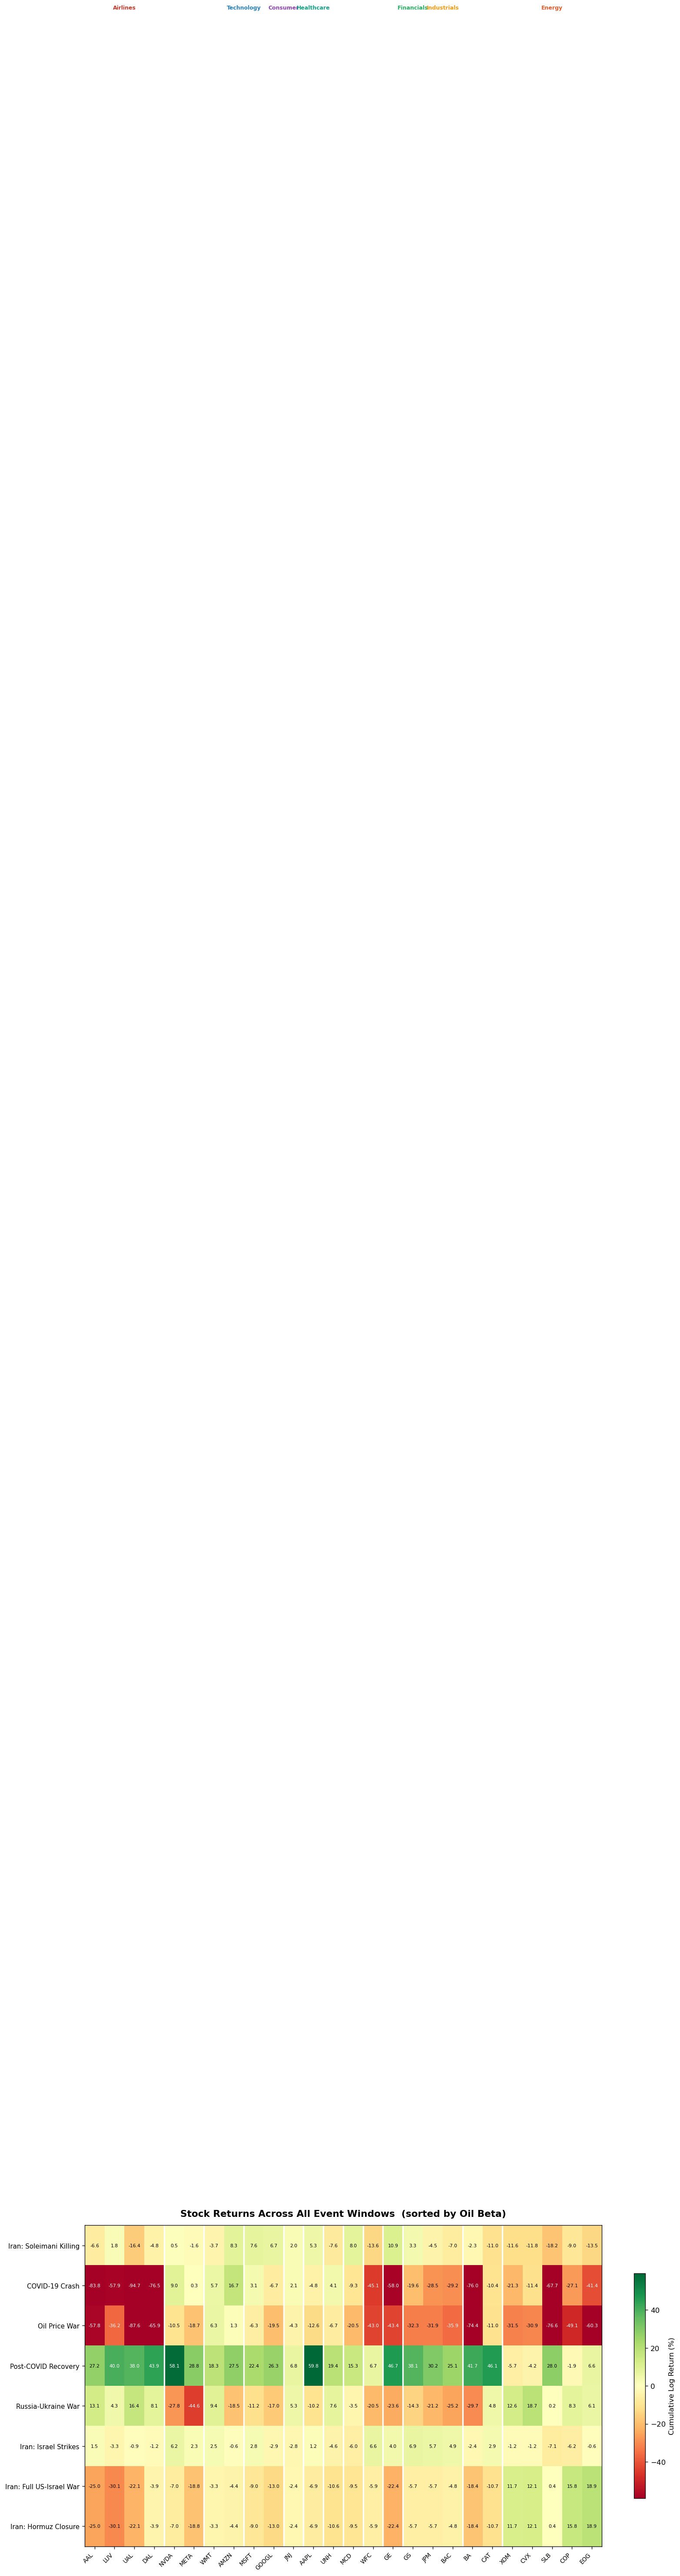

In [12]:
plot_event_heatmap(event_returns_mb, betas_df)

---
## Part B — §10 · Beta vs Actual Return — Model Validation

These scatter plots test whether the full-sample oil beta (x-axis) predicts actual stock
returns during each event (y-axis).

- **Iran War 2025–26** — a supply shock: expect a *positive* slope (high-β stocks did better)
- **COVID-19 Crash** — a demand shock: expect a *flat or weak* slope (everything fell together)

The difference in slope between these two events is the clearest proof that supply-driven
and demand-driven oil shocks operate through fundamentally different channels.

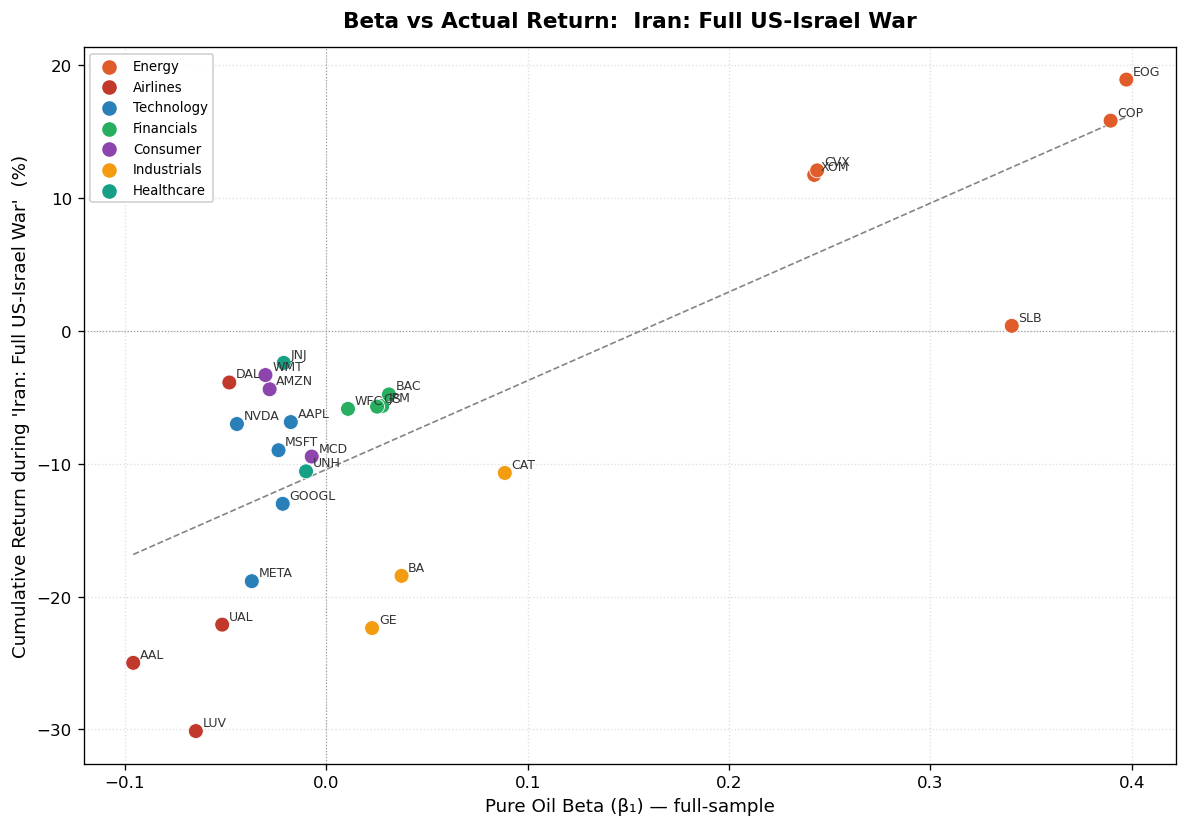

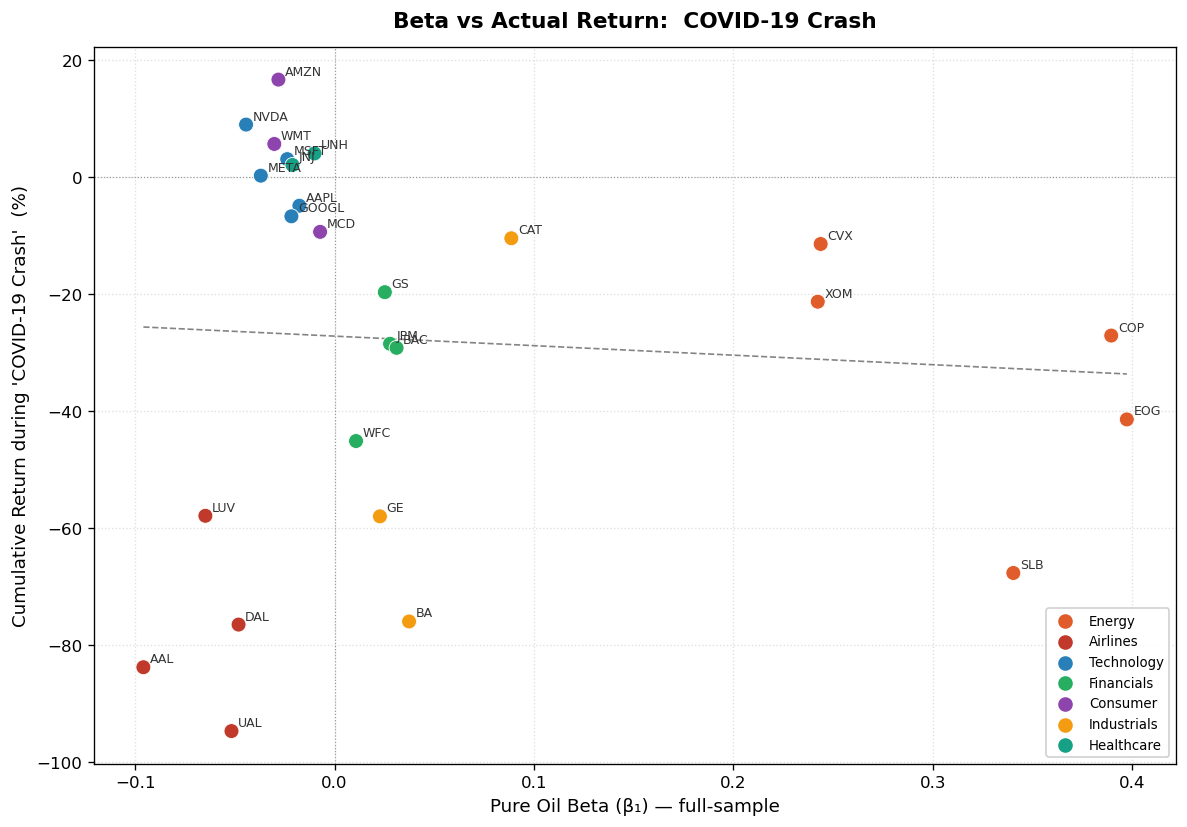

In [13]:
plot_event_beta_scatter(betas_df, event_returns_mb, "Iran: Full US-Israel War")
plot_event_beta_scatter(betas_df, event_returns_mb, "COVID-19 Crash")

---
## Part B — §11 · Individual Stock Deep-Dive

Full multi-regression output for four stocks representing contrasting sectors:
XOM (Energy), DAL (Airlines), NVDA (Technology), JPM (Financials).

The β₁ coefficients should confirm the sector narrative while β₂ and β₃ show
how strongly each stock co-moves with the broad market and volatility regime.

In [14]:
def print_stock_regression(ticker, returns_mb):
    regressors = returns_mb[["Oil", "SPX", "VIX"]]
    res = multi_regression(returns_mb[ticker], regressors)
    sector = SECTORS.get(ticker, "Unknown")

    print(f"{'=' * 58}")
    print(f"  MULTI-REGRESSION: {ticker}  ({sector})")
    print(f"  Model: {ticker}(t) = α + β₁·Oil + β₂·SPX + β₃·VIX + ε")
    print(f"{'=' * 58}")
    labels = ["α  (Intercept)", "β₁  Oil      ", "β₂  SPX      ", "β₃  VIX      "]
    for i, lbl in enumerate(labels):
        sig = "***" if res["p_values"][i] < 0.001 else               "**"  if res["p_values"][i] < 0.01  else               "*"   if res["p_values"][i] < 0.05  else "  "
        print(f"  {lbl} :  {res['betas'][i]:>9.6f}   "
              f"t = {res['t_stats'][i]:>7.3f}   "
              f"p = {res['p_values'][i]:.2e}  {sig}")
    print(f"  {'-'*53}")
    print(f"  R²            : {res['r_squared']:.4f}")
    print(f"  Adjusted R²   : {res['adj_r_squared']:.4f}")
    print(f"  Observations  : {res['n']:,}")
    print(f"  Interpretation: a 1% oil move → {res['beta_oil']*100:.4f}% in {ticker}")
    print(f"                  (controlling for S&P 500 and VIX)")
    print()

for ticker in ["XOM", "DAL", "NVDA", "JPM"]:
    if ticker in returns_mb.columns:
        print_stock_regression(ticker, returns_mb)

  MULTI-REGRESSION: XOM  (Energy)
  Model: XOM(t) = α + β₁·Oil + β₂·SPX + β₃·VIX + ε
  α  (Intercept) :   0.000026   t =   0.108   p = 1.00e+00    
  β₁  Oil       :   0.242312   t =  27.876   p = 1.71e-149  ***
  β₂  SPX       :   0.704992   t =  21.611   p = 1.56e-91  ***
  β₃  VIX       :   0.006275   t =   1.402   p = 3.23e-01    
  -----------------------------------------------------
  R²            : 0.4363
  Adjusted R²   : 0.4357
  Observations  : 2,843
  Interpretation: a 1% oil move → 24.2312% in XOM
                  (controlling for S&P 500 and VIX)

  MULTI-REGRESSION: DAL  (Airlines)
  Model: DAL(t) = α + β₁·Oil + β₂·SPX + β₃·VIX + ε
  α  (Intercept) :  -0.000331   t =  -0.834   p = 8.24e-01    
  β₁  Oil       :  -0.048123   t =  -3.398   p = 1.43e-03  **
  β₂  SPX       :   1.280217   t =  24.088   p = 9.39e-113  ***
  β₃  VIX       :  -0.011925   t =  -1.636   p = 2.03e-01    
  -----------------------------------------------------
  R²            : 0.3306
  Adjusted 

---
## Conclusions

### Part A — Oil vs S&P 500

| Finding | Detail |
|---|---|
| Baseline relationship is weak | Oil explains only 5.4% of daily S&P 500 variation (R² = 0.054) |
| β is highly significant | t = 12.69, p = 4.28 × 10⁻³⁷ — not random |
| Relationship is not stable | 30-day rolling correlation swings from −0.92 to +0.80 |
| Geopolitical shocks reverse the sign | Iran War 2025–26: oil +41.4%, SPX −5.2%, correlation −0.50 |
| Shock frequency is high | Oil moved >3% on 17.4% of all trading days |

### Part B — Multi-Stock Multiple Regression

| Finding | Detail |
|---|---|
| Sector heterogeneity is large | Energy β_oil ≈ +0.20 to +0.30; Airlines β_oil ≈ −0.10 to −0.15 |
| Pure β_oil differs from naïve β | Controlling for SPX and VIX changes the oil coefficient significantly for financials and industrials |
| Iran War validates the model | Stocks with higher full-sample β_oil delivered better cumulative returns during the supply shock |
| COVID does not validate it | During a demand-driven collapse, cross-sectional β_oil was not predictive — everything fell |
| Tech is genuinely insulated | AAPL, MSFT, NVDA show near-zero β_oil with high statistical confidence |

### Central Conclusion

> The oil–equity relationship is dynamic, regime-dependent, and sector-specific.  
> A supply-driven oil shock (geopolitical) and a demand-driven shock (recession/pandemic)  
> produce opposite cross-sectional patterns across S&P 500 stocks.  
> The direction of oil's causality — not just its magnitude — determines whether  
> Energy stocks outperform Airlines or whether the two move together.